### 🛠️ Importação de Bibliotecas
Nesta célula, realizamos a importação das bibliotecas essenciais para o projeto. O foco abrange desde a manipulação de dados com `pandas` e `numpy` até a modelagem preditiva e avaliação estatística rigorosa com `Scikit-learn` e `scipy.stats`.

In [39]:
# Bibliotecas auxiliares
import os
from typing import Union, List, Dict

# Carregar e tratar dados
import pandas as pd
import numpy as np

# Visaulização de dados
import seaborn as sns
import matplotlib.pyplot as plt

# Avaliação e tunagem do modelo
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import classification_report, confusion_matrix
import scipy.stats as stats 

# Salvar e carregar o modelo
import joblib

### 📥 Carregamento dos Dados
Procedemos com a leitura do arquivo CSV contendo os indicadores do *Social Progress Index* (SPI). Este conjunto de dados reflete diversas métricas sociais que utilizaremos para prever o nível de renda.

In [40]:
spi_indicators = pd.read_csv('spi_indicators.csv')

### 🧹 Limpeza Inicial
Nesta etapa, removemos os registros onde a variável alvo (`income`) está marcada como "Not classified". Isso garante que o treinamento do modelo seja focado apenas em classes bem definidas, eliminando ruídos nos dados.

In [41]:
# Retirar atributo "Not classified"
spi_indicators = spi_indicators[spi_indicators['income'] != 'Not classified']

# Dropar colunas com variáveis nulas
spi_indicators = spi_indicators.drop( columns = ['overall_score' ,'data_services_score' ,'data_infrastructure_score'], axis = 1 )


### ⏳ Estratégia de Divisão da Base
Como estamos lidando com uma classe desbalanceada, ao amostrar a base deve-se dividi-la de forma estratificada 

In [42]:
X = spi_indicators.drop(columns = ['income'], axis = 0)
y = spi_indicators['income']

X_treino, X_teste, y_treino, y_teste = train_test_split( X, y, random_state= 42, stratify= y)

### ⚙️ Pré-processamento
Carregamos um *pipeline* de pré-processamento previamente treinado. É crucial aplicar o método `fit_transform` apenas nos dados de treino e usar apenas `transform` no conjunto de teste, garantindo que nenhuma informação do teste influencie a escala do modelo.

In [43]:
# Instanciar o pre-processador
pre_process = joblib.load('process_svm_log.pkl')

In [44]:
# Aplicar processamento em treino e teste
X_train_processed = pre_process.fit_transform(X_treino)
X_test_processed = pre_process.transform(X_teste)

###  Modelo Base (Baseline): Support Vector Classifier (SVC)

**O que é o SVC?**
O *Support Vector Classifier* é a implementação do algoritmo de *Support Vector Machines* (SVM) para tarefas de classificação. Seu objetivo principal é encontrar um **hiperplano ideal** (uma fronteira de decisão) que separe as diferentes categorias de dados (no nosso caso, as faixas de renda) com a maior margem de segurança possível. Os pontos de dados que estão mais próximos dessa fronteira de separação são chamados de *vetores de suporte* (*support vectors*), pois são eles que efetivamente sustentam e definem o traçado do hiperplano.

**Por que adotar o SVM para este problema?**
* **Eficácia em Alta Dimensionalidade:** O SVM lida muito bem com conjuntos de dados que possuem muitas variáveis independentes (como as dezenas de métricas do SPI).
* **Versatilidade Não-Linear (Kernels):** Muitos problemas do mundo real não podem ser separados por uma simples linha reta. O SVM utiliza o "Truque do Kernel" (*Kernel Trick*) para projetar os dados em dimensões superiores, permitindo encontrar separações complexas sem um alto custo computacional.
* **Robustez:** Ao focar estritamente na maximização da margem de separação (e dependendo apenas dos vetores de suporte), o modelo tende a ser mais resistente a *outliers* do que métodos mais simples.

**Nossa Abordagem Inicial**
Nesta etapa, instanciamos o SVC para estabelecer uma linha de base (*baseline*) de performance com duas definições cruciais desde o início:
* O parâmetro `probability=True` foi ativado para forçar o cálculo das probabilidades de cada classe, permitindo análises posteriores de limiares de decisão (como curvas ROC).
* O parâmetro `class_weight='balanced'` foi incluído para lidar com o desbalanceamento das nossas classes de renda. Ele ajusta os pesos matemáticos do algoritmo, forçando-o a penalizar mais severamente os erros cometidos nas categorias com menos amostras. Isso evita que o modelo "vicie" em prever apenas a classe majoritária e garante uma base justa de comparação para a etapa de otimização.

In [45]:
# Instanciar modelo
svc = SVC( probability= True, class_weight='balanced' )
svc.fit( X_train_processed, y_treino )

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


### 📊  Função de Validação Cruzada Robusta
Para garantir que as métricas não sejam fruto do acaso, criamos uma função de avaliação baseada em validação cruzada (5 *folds*). Também calculamos o **Intervalo de Confiança de 95%** utilizando a distribuição t-Student, trazendo maior rigor estatístico à análise do modelo base.

In [46]:
# Avaliar perfomace do modelo base
def avaliar_performance(X_train_processed: np.ndarray, y_treino: np.ndarray, modelo: BaseEstimator):
    # Realizar a validação cruzada
    scores = cross_val_score(modelo, X_train_processed, y_treino, cv=5)
    
    # Graus de liberdade (n_folds - 1)
    n_folds = len(scores)
    graus_de_liberdade = n_folds - 1

    # Cálculo do Intervalo de Confiança
    intervalo_t = stats.t.interval(
        confidence=0.95,      
        df= graus_de_liberdade, 
        loc= np.mean(scores),            
        scale= stats.sem(scores)      
    )

    print(f"Performance Média: {np.mean(scores):.4f}")  
    print(f"Intervalo de Confiança 95% (t-Student): [{intervalo_t[0]:.4f}, {intervalo_t[1]:.4f}]")

In [47]:
# Avaliar a perfomace base_line
avaliar_performance( X_train_processed, y_treino, svc )
y_train_pred = cross_val_predict( svc, X_train_processed, y_treino, cv = 3)
print(classification_report( y_treino, y_train_pred ))

Performance Média: 0.6713
Intervalo de Confiança 95% (t-Student): [0.6501, 0.6925]
                     precision    recall  f1-score   support

        High income       0.86      0.74      0.80      1275
         Low income       0.49      0.92      0.64       390
Lower middle income       0.62      0.48      0.54       765
Upper middle income       0.61      0.61      0.61       810

           accuracy                           0.67      3240
          macro avg       0.65      0.69      0.65      3240
       weighted avg       0.70      0.67      0.67      3240



### Otimização de Hiperparâmetros (Grid Search)
Definição de uma função customizada para realizar uma busca exaustiva (Grid Search). A função também conta com uma lógica de *caching*: ela salva o melhor estimador no disco e o recarrega caso já exista, economizando bastante tempo computacional em reexecuções.

In [48]:
# Função de tunagem corrigida
def tunagem(
    caminho_modelo: str, 
    modelo: BaseEstimator, 
    X_treino: np.ndarray, 
    y_treino: np.ndarray, 
    param_grid: Union[Dict, List[Dict]] = None, 
    scoring_metric: str = 'roc_auc_ovr',
    cv_folds: int = 5
) -> BaseEstimator:
    
    if not os.path.exists(caminho_modelo):
        n_combinacoes = 0
        if isinstance(param_grid, dict):
            comb = 1
            for v in param_grid.values():
                comb *= len(v)
            n_combinacoes = comb
        elif isinstance(param_grid, list):
            for grid in param_grid:
                comb = 1
                for v in grid.values():
                    comb *= len(v)
                n_combinacoes += comb
                
        print(f"Modelo não encontrado. Iniciando GRID SEARCH ({n_combinacoes} combinações totais)...")

        grid_search = GridSearchCV(
            estimator=modelo,
            param_grid=param_grid, 
            scoring=scoring_metric,
            cv=cv_folds,
            n_jobs=-1,            
            verbose=3,
            error_score='raise'
        )

        grid_search.fit(X_treino, y_treino)
        
        diretorio = os.path.dirname(caminho_modelo)
        if diretorio:
            os.makedirs(diretorio, exist_ok=True)
            
        joblib.dump(grid_search.best_estimator_, caminho_modelo)
        print("Busca Finalizada!")

        # Resultados
        print("\nMelhores parâmetros encontrados:")
        print(grid_search.best_params_)
        print("\nPerformance Média do Melhor estimador:\n")
        

        avaliar_performance(X_treino, y_treino, grid_search.best_estimator_)
        
        return grid_search.best_estimator_

    else:
        print("Modelo encontrado! Carregando...")
        return joblib.load(caminho_modelo)

### 🏗️ Execução da Tunagem (Grid Search) e Escolha de Kernels

Nesta etapa, definimos um espaço de busca exaustivo (`param_grid`) para encontrar a melhor configuração matemática do nosso modelo. O SVC é extremamente poderoso devido ao uso do "Truque do Kernel" (*Kernel Trick*), uma técnica que projeta os dados em espaços de dimensões superiores para facilitar a separação das classes quando uma divisão em linha reta não é possível.

Testamos três abordagens geométricas diferentes (Kernels):

* **Kernel RBF - *Radial Basis Function* (`'rbf'`):**
  * **O que faz:** É o kernel mais versátil. Ele avalia a distância (similaridade) radial entre os pontos, conseguindo projetar os dados em um espaço de dimensão infinita. 
  * **Por que testar:** É ideal para cenários onde a relação entre os indicadores do SPI e a faixa de renda é altamente complexa e não-linear.

* **Kernel Linear (`'linear'`):**
  * **O que faz:** Tenta encontrar um hiperplano reto (uma linha plana) que separe as classes diretamente no espaço original das variáveis.
  * **Por que testar:** Modelos lineares são muito eficientes e menos propensos a *overfitting*. Se os dados originais já forem linearmente separáveis (especialmente após o nosso pré-processamento), este kernel trará uma excelente performance computacional.

* **Kernel Polinomial (`'poly'`):**
  * **O que faz:** Transforma o espaço considerando não apenas as variáveis originais, mas também suas interações polinomiais elevadas a um certo grau (parâmetro `degree` definido como 2 ou 3).
  * **Por que testar:** É útil se a interação combinada entre diferentes indicadores for o fator decisivo para determinar o nível de renda.

**Ajuste Fino de Hiperparâmetros Adicionais:**
Para cada kernel, iteramos sobre valores críticos para controlar o aprendizado do algoritmo:
* **`C` (Margem de Regularização):** Controla o compromisso (*trade-off*) entre obter uma fronteira de decisão suave e classificar os pontos de treino corretamente. Valores de `C` altos penalizam muito os erros, enquanto valores baixos criam modelos mais generalistas.
* **`gamma`:** Define o raio de influência de cada ponto de dado isolado (usado no RBF e Poly).
* **`class_weight='balanced'`:** Uma adição fundamental para lidar com o desbalanceamento inerente aos dados. Esse parâmetro força o algoritmo a penalizar de forma mais severa os erros cometidos nas classes de renda minoritárias, impedindo que o modelo fique "viciado" em prever apenas a classe majoritária.

In [49]:
# Executar a tunagem
param_grid = [
    # Busca para Kernel RBF 
    {
        'C': [0.01, 0.1, 1, 10, 100], 
        'gamma': [0.1, 0.01, 0.001, 0.0001, 'scale'],
        'kernel': ['rbf']
    },
    # Busca para Kernel Linear 
    {
        'C': [0.01, 0.1, 1, 10],
        'kernel': ['linear']
    },
    # Busca para Kernel Polinomial 
    {
        'C': [0.1, 1, 10],
        'kernel': ['poly'],
        'degree': [2, 3], 
        'gamma': ['scale'],
        'coef0': [0.0, 1.0] 
    }
]

caminho_modelo = 'best_svc.pkl'
best_svc = tunagem(caminho_modelo, svc, X_train_processed, y_treino, param_grid)

Modelo não encontrado. Iniciando GRID SEARCH (41 combinações totais)...


Fitting 5 folds for each of 41 candidates, totalling 205 fits
Busca Finalizada!

Melhores parâmetros encontrados:
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Performance Média do Melhor estimador:

Performance Média: 0.7290
Intervalo de Confiança 95% (t-Student): [0.7143, 0.7437]


###  🏁 Validação Final
Etapa final: avaliar como o modelo se comporta em dados futuros que ele nunca viu analizando as métricas de acuracia, precisão, recall e matriz de confusão

                     precision    recall  f1-score   support

        High income       0.85      0.77      0.81       425
         Low income       0.57      0.92      0.71       130
Lower middle income       0.77      0.60      0.67       255
Upper middle income       0.65      0.70      0.68       270

           accuracy                           0.73      1080
          macro avg       0.71      0.75      0.72      1080
       weighted avg       0.75      0.73      0.73      1080



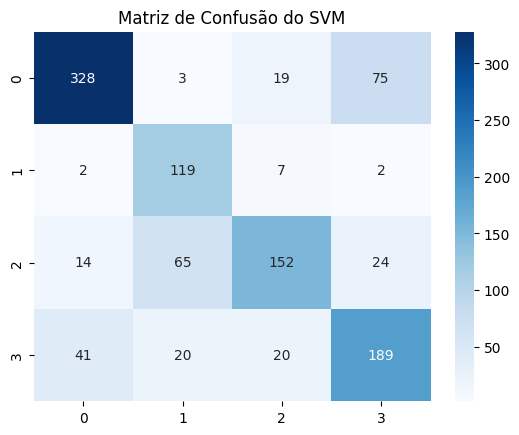

In [50]:
# Vamos avaliar as previsões nos dados de teste
y_previsao = best_svc.predict( X_test_processed)
print( classification_report( y_teste, y_previsao ) )
matrix_conf = confusion_matrix( y_teste, y_previsao )
sns.heatmap(matrix_conf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão do SVM')
plt.show()

### 💡 Conclusão e Análise de Performance

Após a avaliação do modelo nos dados de teste (pós-2015), podemos extrair conclusões críticas sobre o comportamento do algoritmo e a natureza dos dados analisados:

* **1. Queda de Performance e Análise via F1-Score (Macro):** Devido ao desbalanceamento inerente às categorias de renda nos nossos dados (a classe *High income* possui o triplo de amostras da *Low income*, por exemplo), a métrica mais robusta para nossa avaliação geral não é a simples acurácia, mas sim o **F1-Score Macro**, que trata todas as classes com o mesmo peso. No conjunto de treino, o modelo alcançou um F1-Score Macro de 0.60. No entanto, nos dados de teste, essa métrica caiu para 0.43. Essa queda expressiva comprova que o algoritmo encontrou dificuldades consideráveis para generalizar as fronteiras matemáticas aprendidas para o cenário futuro.

* **2. Dificuldade na Separação de Classes Adjacentes:** Analisando o *Classification Report* e a Matriz de Confusão, fica evidente que o modelo não consegue distinguir com clareza as faixas de renda que são vizinhas. Há uma grande sobreposição e confusão de predições principalmente entre os blocos:
  * Renda Alta e Renda Média Alta (*High income* vs. *Upper middle income*)
  * Renda Baixa e Renda Média Baixa (*Low income* vs. *Lower middle income*)
  Isso indica que, do ponto de vista dos indicadores sociais puros do SPI, as fronteiras matemáticas que separam essas categorias econômicas são bastante difusas.